In [1]:
import pandas as pd
import numpy as np
import sentencepiece as spm
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#why sentencepiece

Transformer not understand text directly so we need to convert into numbers.
so we dont use simple word tokenizer we use subword tokenizer beacuse English +
Hindi vocabulary may be large


In [3]:
import pandas as pd

# Load processed datasets
train_df = pd.read_parquet(
    '/content/drive/MyDrive/Translation Language Translator /processed/train_processed.parquet'
)

validation_df = pd.read_parquet(
    '/content/drive/MyDrive/Translation Language Translator /processed/validation_processed.parquet'
)

test_df = pd.read_parquet(
    '/content/drive/MyDrive/Translation Language Translator /processed/test_processed.parquet'
)

In [4]:
#check dataset
print("Total train_df sentence pairs:", len(train_df))

print("\nColumns:")
print(train_df.columns.tolist())

print("\nMissing values:")
print(train_df.isnull().sum())

print('-*'*20)

print("Total validation_df sentence pairs:", len(validation_df))

print("\nColumns:")
print(validation_df.columns.tolist())

print("\nMissing values:")
print(validation_df.isnull().sum())

print('-*'*20)
print("Total test_df sentence pairs:", len(test_df))

print("\nColumns:")
print(test_df.columns.tolist())

print("\nMissing values:")
print(test_df.isnull().sum())

Total train_df sentence pairs: 1374653

Columns:
['english', 'hindi']

Missing values:
english    0
hindi      0
dtype: int64
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Total validation_df sentence pairs: 520

Columns:
['english', 'hindi']

Missing values:
english    0
hindi      0
dtype: int64
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Total test_df sentence pairs: 2507

Columns:
['english', 'hindi']

Missing values:
english    0
hindi      0
dtype: int64


In [5]:
#create tokenizer training file
'''
i create seperate file of both language beacuse both language carring writing and
linguistic structure different
'''

train_df['english'].to_csv(
    'english_tokenizer.txt',
    index=False,
    header=False
)
train_df['hindi'].to_csv(
    'hindi_tokenizer.txt',
    index=False,
    header=False
)

In [8]:
#train endlish sentence piece tokenizer
#creating english subword vocabulary
spm.SentencePieceTrainer.train(
    input="english_tokenizer.txt",
    model_prefix="english_sp",
    vocab_size=16000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

True

In [9]:
#train hindi senetence piece tokenizer
spm.SentencePieceTrainer.train(
    input="hindi_tokenizer.txt",
    model_prefix="hindi_sp",
    vocab_size=16000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

True

In [11]:
#load tokenizers
english_tokenizer = spm.SentencePieceProcessor(
    model_file="english_sp.model"
)

hindi_tokenizer = spm.SentencePieceProcessor(
    model_file="hindi_sp.model"
)

In [12]:
print("English vocabulary:",
      english_tokenizer.get_piece_size())

print("Hindi vocabulary:",
      hindi_tokenizer.get_piece_size())

English vocabulary: 16000
Hindi vocabulary: 16000


In [14]:
#test english tokenization
text = "How are you?"

tokens = english_tokenizer.encode(
    text,
    out_type=str
)

print("Original:", text)
print("Tokens:", tokens)

'''
▁  -> SentencePiece uses this symbol to represent a word boundary.
'''

Original: How are you?
Tokens: ['▁How', '▁are', '▁you', '?']


'\n▁  -> SentencePiece uses this symbol to represent a word boundary.\n'

In [15]:
#convert token to IDS
token_ids = english_tokenizer.encode(
    text,
    out_type=int
)
print('Original: ', text)
print('Token IDs: ', token_ids)

Original:  How are you?
Token IDs:  [1900, 111, 86, 15631]


In [16]:
#test hindi tokenization
text = "आप कैसे हैं?"

tokens = hindi_tokenizer.encode(
    text,
    out_type=str
)

print("Original:", text)
print("Tokens:", tokens)

Original: आप कैसे हैं?
Tokens: ['▁आप', '▁कैसे', '▁हैं', '?']


In [17]:
tokens = hindi_tokenizer.encode(
    text,
    out_type=int
)

print("Original:", text)
print("Tokens:", tokens)

Original: आप कैसे हैं?
Tokens: [186, 1595, 64, 15630]


In [18]:
#BOS = Beginning Of Sentence
#EOS = End Of Sentence

In [19]:
#create tokenizer helper functions

#english encoder
def encode_english(text):
    return english_tokenizer.encode(
        text,
        out_type=int
    )
#hindi decoder
def encode_hindi(text):
    return hindi_tokenizer.encode(
        text,
        out_type=int
    )

In [20]:
#test
english = "How are you?"
hindi = "आप कैसे हैं?"

print("English IDs:")
print(encode_english(english))

print("\nHindi IDs:")
print(encode_hindi(hindi))

English IDs:
[1900, 111, 86, 15631]

Hindi IDs:
[186, 1595, 64, 15630]


In [23]:
#add BOS/EOS to hindi
'''
generally encoder BOS are not required but decoder target sequence
EOS is important
'''
def encode_hindi_with_special_tokens(text):
    tokens = hindi_tokenizer.encode(
        text,
        out_type=int
    )

    return [hindi_tokenizer.bos_id()] + tokens + [hindi_tokenizer.eos_id()]

In [24]:
text = "आप कैसे हैं?"

ids = encode_hindi_with_special_tokens(text)

print(ids)

[2, 186, 1595, 64, 15630, 3]


In [25]:
#create decoder sequences
def create_decoder_sequences(text):
    tokens = hindi_tokenizer.encode(
        text,
        out_type=int
    )

    bos = hindi_tokenizer.bos_id()
    eos = hindi_tokenizer.eos_id()

    decoder_input = [bos] + tokens
    decoder_target = tokens + [eos]

    return decoder_input, decoder_target

In [26]:
text = "आप कैसे हैं?"

decoder_input, decoder_target = create_decoder_sequences(text)

print("Decoder Input :")
print(decoder_input)

print("\nDecoder Target:")
print(decoder_target)

Decoder Input :
[2, 186, 1595, 64, 15630]

Decoder Target:
[186, 1595, 64, 15630, 3]


In [27]:
#Token lengths calculate
english_lengths = []
hindi_lengths = []

for text in train_df["english"]:
    english_lengths.append(
        len(english_tokenizer.encode(text, out_type=int))
    )

for text in train_df["hindi"]:
    hindi_lengths.append(
        len(hindi_tokenizer.encode(text, out_type=int))
    )

english_lengths = np.array(english_lengths)
hindi_lengths = np.array(hindi_lengths)

print("English token statistics:")
print(pd.Series(english_lengths).describe())

print("\nHindi token statistics:")
print(pd.Series(hindi_lengths).describe())

English token statistics:
count    1.374653e+06
mean     1.582705e+01
std      1.339607e+01
min      1.000000e+00
25%      5.000000e+00
50%      1.200000e+01
75%      2.300000e+01
max      2.190000e+02
dtype: float64

Hindi token statistics:
count    1.374653e+06
mean     1.692092e+01
std      1.440583e+01
min      1.000000e+00
25%      5.000000e+00
50%      1.300000e+01
75%      2.500000e+01
max      4.010000e+02
dtype: float64


In [28]:
percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]

print("English token lengths:")
print(np.percentile(english_lengths, percentiles))

print("\nHindi token lengths:")
print(np.percentile(hindi_lengths, percentiles))

English token lengths:
[12. 23. 35. 43. 56. 61. 72.]

Hindi token lengths:
[13. 25. 38. 46. 59. 64. 78.]


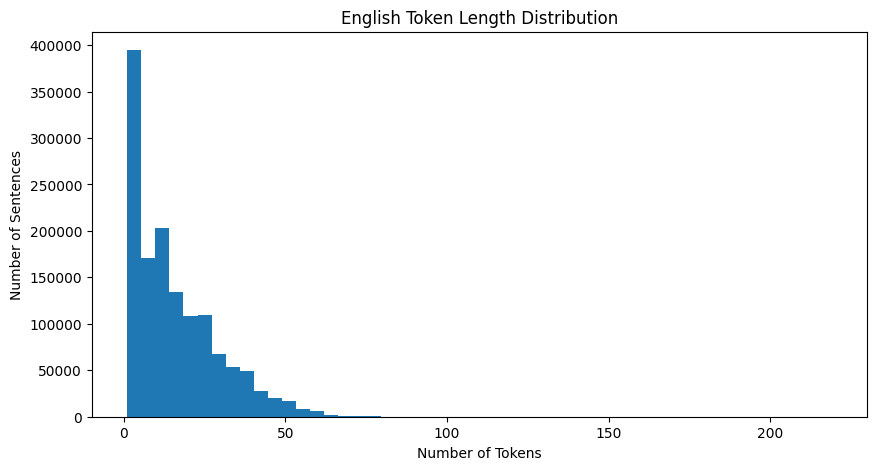

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(english_lengths, bins=50)

plt.xlabel("Number of Tokens")
plt.ylabel("Number of Sentences")
plt.title("English Token Length Distribution")

plt.show()

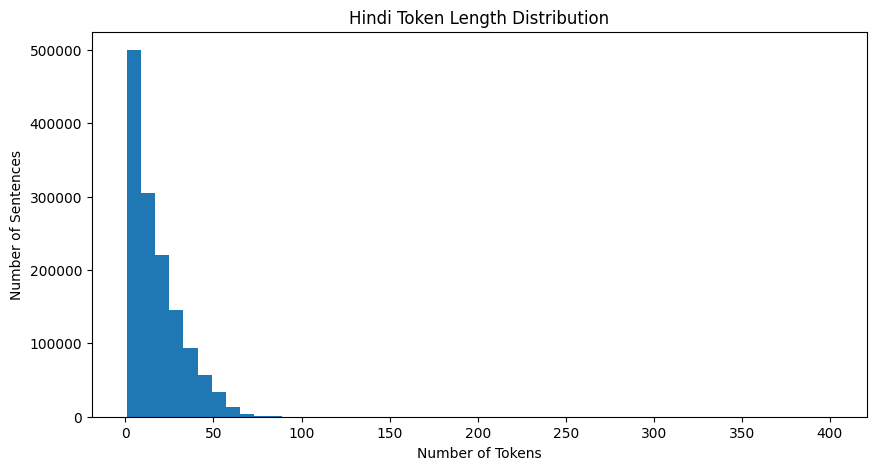

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(hindi_lengths, bins=50)

plt.xlabel("Number of Tokens")
plt.ylabel("Number of Sentences")
plt.title("Hindi Token Length Distribution")

plt.show()

In [32]:
print("Longest English sentence:")
english_max_idx = np.argmax(english_lengths)

print("Tokens:", english_lengths[english_max_idx])
print("Text:", train_df.iloc[english_max_idx]["english"])

Longest English sentence:
Tokens: 219
Text: BASE, BESSELI, BESSELJ, BESSELK, BESSELY, BIN2DEC, BIN2HEX, BIN2OCT, COMPLEX, CONVERT, DEC2BIN, DEC2HEX, DEC2OCT, DELTA, ERF, ERFC, GESTEP, HEX2BIN, HEX2DEC, HEX2OCT, IMABS, IMAGINARY, IMARGUMENT, IMCONJUGATE, IMCOS, IMCOSH, IMDIV, IMEXP, IMLN, IMLOG10, IMLOG2, IMPOWER, IMPRODUCT, IMREAL, IMSIN, IMSINH, IMSQRT, IMSUB, IMSUM, IMTAN, IMTANH, OCT2BIN, OCT2DEC, OCT2HEX


In [33]:
print("\nLongest Hindi sentence:")
hindi_max_idx = np.argmax(hindi_lengths)

print("Tokens:", hindi_lengths[hindi_max_idx])
print("Text:", train_df.iloc[hindi_max_idx]["hindi"])


Longest Hindi sentence:
Tokens: 401
Text: à¤ à¤à¤¯ à¤ à¤°à¥à¤£ à¤ à¤à¤¿à¤² à¤ à¤à¤°à¤® à¤à¤à¤¡à¥à¤°à¤¯à¥ à¤¬à¤¾à¤¬à¥ à¤¬à¤à¤à¤¿à¤® à¤¬à¤¸à¤à¤¤ à¤¸à¤à¤à¤¯ à¤¸à¥à¤¶à¥à¤² à¤¦à¥à¤µà¥à¤¨à¥à¤¦à¥à¤° à¤¦à¤¯à¤¾à¤² à¤¦à¥à¤²à¤¤ à¤à¤°à¤«à¤¾à¤¨ à¤à¤®à¤¿à¤²à¥ à¤à¤¶à¥à¤µà¤° à¤à¤£à¥à¤¶ à¤à¥à¤²à¤¾à¤¬ à¤à¥à¤²à¥ à¤¹à¤°à¥ à¤à¤à¤¾à¤ à¤à¤¾à¤²à¤¿à¤® à¤à¥à¤¹à¤¨ à¤à¤²à¤¾à¤²à¥à¤¦à¥à¤¦à¥à¤¨ à¤à¥à¤µà¤¨ à¤à¥à¤£à¤¾à¤² à¤à¤°à¥à¤® à¤à¤¾à¤²à¥ à¤à¤®à¤² à¤®à¥à¤¹à¤¨ à¤®à¤¦à¤¨ à¤¨à¥à¤²à¤® à¤¨à¥à¤²à¤¿à¤®à¤¾ à¤ªà¤¾à¤² à¤°à¤¾à¤®à¥ à¤°à¤¾à¤à¥ à¤¸à¥à¤¹à¤¨ à¤¶à¤¾à¤¹à¤°à¥à¤ à¤¤à¥à¤«à¤¼à¥à¤ à¤¤à¤°à¥à¤£ à¤µà¤¾à¤¸à¤¿à¤® à¤à¤¾à¤¸à¤¿à¤®


In [36]:
english_p99 = np.percentile(english_lengths, 99)
hindi_p99 = np.percentile(hindi_lengths, 99)

MAX_ENGLISH_LEN = int(np.ceil(english_p99 / 8) * 8)
MAX_HINDI_LEN = int(np.ceil(hindi_p99 / 8) * 8)

print("English P99:", english_p99)
print("Hindi P99  :", hindi_p99)

print("\nMAX_ENGLISH_LEN:", MAX_ENGLISH_LEN)
print("MAX_HINDI_LEN  :", MAX_HINDI_LEN)

English P99: 56.0
Hindi P99  : 59.0

MAX_ENGLISH_LEN: 56
MAX_HINDI_LEN  : 64


In [37]:
#create padding function
PAD_ID = 0

def pad_sequence(token_ids, max_len):

    # Truncate if sequence is too long
    token_ids = token_ids[:max_len]

    # Calculate required padding
    padding_length = max_len - len(token_ids)

    # Add PAD tokens
    token_ids = token_ids + [PAD_ID] * padding_length

    return token_ids

In [38]:
tokens = english_tokenizer.encode(
    "How are you?",
    out_type=int
)

print("Original:", tokens)

padded = pad_sequence(
    tokens,
    MAX_ENGLISH_LEN
)

print("Padded:", padded)
print("Length:", len(padded))

Original: [1900, 111, 86, 15631]
Padded: [1900, 111, 86, 15631, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 56


In [49]:
# English encoder preprocessing
def preprocess_english(text):

    tokens = english_tokenizer.encode(
        text,
        out_type=int
    )

    tokens = pad_sequence(
        tokens,
        MAX_ENGLISH_LEN
    )

    return tokens

In [54]:
#Hindi decoder preprocessing
BOS_ID = hindi_tokenizer.bos_id()
EOS_ID = hindi_tokenizer.eos_id()

def preprocess_hindi(text):

    tokens = hindi_tokenizer.encode(
        text,
        out_type=str
    )

    # Decoder input
    decoder_input = [BOS_ID] + tokens

    # Decoder target
    decoder_target = tokens + [EOS_ID]

    # Padding
    decoder_input = pad_sequence(
        decoder_input,
        MAX_HINDI_LEN
    )

    decoder_target = pad_sequence(
        decoder_target,
        MAX_HINDI_LEN
    )

    return decoder_input, decoder_target

In [55]:
#test
english = "How are you?"
hindi = "आप कैसे हैं?"

encoder_input = preprocess_english(english)

decoder_input, decoder_target = preprocess_hindi(hindi)

print("Encoder Input:")
print(encoder_input)

print("\nDecoder Input:")
print(decoder_input)

print("\nDecoder Target:")
print(decoder_target)

Encoder Input:
[1900, 111, 86, 15631, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decoder Input:
[2, '▁आप', '▁कैसे', '▁हैं', '?', 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Decoder Target:
['▁आप', '▁कैसे', '▁हैं', '?', 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [57]:
#check BOS/EOS/PAD
print("PAD:", PAD_ID)
print("BOS:", BOS_ID)
print("EOS:", EOS_ID)

PAD: 0
BOS: 2
EOS: 3


In [60]:
print("Decoder input first token:", decoder_input[0])
print(hindi_tokenizer.id_to_piece(decoder_input[0]))

Decoder input first token: 2
<s>


In [59]:
print("Decoder target before padding:")
print(decoder_target[:20])

Decoder target before padding:
['▁आप', '▁कैसे', '▁हैं', '?', 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [64]:
BASE_PATH = "/content/drive/MyDrive/Translation Language Translator "

os.makedirs(f"{BASE_PATH}/processed", exist_ok=True)
os.makedirs(f"{BASE_PATH}/tokenized", exist_ok=True)

print("Folders ready!")

Folders ready!


In [65]:
train_df = pd.read_parquet(
    f"{BASE_PATH}/processed/train_processed.parquet"
)

print(train_df.shape)
print(train_df.head())

(1374653, 2)
                                          english  \
0  Give your application an accessibility workout   
1               Accerciser Accessibility Explorer   
2  The default plugin layout for the bottom panel   
3     The default plugin layout for the top panel   
4  A list of plugins that are disabled by default   

                                               hindi  
0    अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें  
1                    एक्सेर्साइसर पहुंचनीयता अन्वेषक  
2              निचले पटल के लिए डिफोल्ट प्लग-इन खाका  
3               ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका  
4  उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...  


In [66]:
#dont tokenize all 1.65M at once beacuse RAM usage under control so i doning this into chunk

CHUNK_SIZE = 100_000
def tokenize_batch(df):

    encoder_inputs = []
    decoder_inputs = []
    decoder_targets = []

    for english, hindi in zip(
        df["english"],
        df["hindi"]
    ):

        # English → Encoder
        english_tokens = english_tokenizer.encode(
            english,
            out_type=int
        )

        english_tokens = pad_sequence(
            english_tokens,
            MAX_ENGLISH_LEN
        )

        # Hindi → Decoder
        hindi_tokens = hindi_tokenizer.encode(
            hindi,
            out_type=int
        )

        decoder_input = [BOS_ID] + hindi_tokens
        decoder_target = hindi_tokens + [EOS_ID]

        decoder_input = pad_sequence(
            decoder_input,
            MAX_HINDI_LEN
        )

        decoder_target = pad_sequence(
            decoder_target,
            MAX_HINDI_LEN
        )

        encoder_inputs.append(english_tokens)
        decoder_inputs.append(decoder_input)
        decoder_targets.append(decoder_target)

    return (
        np.array(encoder_inputs, dtype=np.int32),
        np.array(decoder_inputs, dtype=np.int32),
        np.array(decoder_targets, dtype=np.int32)
    )

In [67]:
TOKENIZED_PATH = f"{BASE_PATH}/tokenized"

total_rows = len(train_df)

print("Total rows:", total_rows)
print("Chunk size:", CHUNK_SIZE)

Total rows: 1374653
Chunk size: 100000


In [68]:
for start in range(0, total_rows, CHUNK_SIZE):

    end = min(start + CHUNK_SIZE, total_rows)

    print(f"\nProcessing rows {start:,} → {end:,}")

    chunk_df = train_df.iloc[start:end]

    encoder, decoder_input, decoder_target = tokenize_batch(
        chunk_df
    )

    output_file = (
        f"{TOKENIZED_PATH}/train_chunk_{start//CHUNK_SIZE:03d}.npz"
    )

    np.savez_compressed(
        output_file,
        encoder_inputs=encoder,
        decoder_inputs=decoder_input,
        decoder_targets=decoder_target
    )

    print("Saved:", output_file)


Processing rows 0 → 100,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_000.npz

Processing rows 100,000 → 200,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_001.npz

Processing rows 200,000 → 300,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_002.npz

Processing rows 300,000 → 400,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_003.npz

Processing rows 400,000 → 500,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_004.npz

Processing rows 500,000 → 600,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_005.npz

Processing rows 600,000 → 700,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/train_chunk_006.npz

Processing rows 700,000 → 800,000
Saved: /content/drive/MyDrive/Translation Language Translator /tokenized/tr

In [ ]:
"""
Cleaned English-Hindi Dataset
              ↓
       SentencePiece BPE
              ↓
      ┌───────┴────────┐
      ↓                ↓
 English tokenizer   Hindi tokenizer
      ↓                ↓
 Encoder IDs       Hindi token IDs
                       ↓
              ┌────────┴────────┐
              ↓                 ↓
       Decoder Input      Decoder Target
       [BOS + tokens]     [tokens + EOS]
              ↓                 ↓
          Padding + Truncation
              ↓
        Save as .npz chunks
              ↓
          Google Drive
"""

Project: English → Hindi Transformer Language Translator
Objective

The goal of this notebook is to convert the cleaned English-Hindi parallel corpus into numerical token sequences that can be processed by our Transformer model.

The Transformer cannot directly understand raw text. Therefore, sentences are converted into subword tokens, and those tokens are mapped to integer IDs.